# Chatbot LangGraph — Live Test
Run each cell in order to verify every layer works before running the full pipeline.

## 1. Load environment variables

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()


True

## 2. Langfuse — connection check

In [2]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler

langfuse = get_client()
langfuse_handler = CallbackHandler()

ok = langfuse.auth_check()
print("Langfuse auth:", "OK" if ok else "FAILED")

Langfuse auth: OK


## 3. Milvus — connection check

In [8]:
from db.milvus_handler import MilvusHandler

milvus = MilvusHandler()
collections = milvus.client.list_collections()
print("Connected to Milvus")
print("Collections:", collections)
print(len(collections[0]))

Connected to Milvus
Collections: ['codPenal_collection']
19


## 4. Embedding model — generate a test vector

In [4]:
from langchain_openai import OpenAIEmbeddings

embedding_model = os.getenv("CHATBOT_MODEL_EMBEDDING", "text-embedding-3-large")
embeddings = OpenAIEmbeddings(model=embedding_model)

#je risque quoi si je vole ?
test_text = "ce se intampla daca fur?"
vector = embeddings.embed_query(test_text)

print(f"Model      : {embedding_model}")
print(f"Vector dim : {len(vector)}")
print(f"First 5    : {vector[:5]}")

Model      : text-embedding-3-large
Vector dim : 3072
First 5    : [-0.01342901960015297, -0.02036057971417904, -0.011153507977724075, -0.0020112022757530212, 0.02701207436621189]


## 5. Milvus search — retrieve context with the embedding

In [6]:
context = milvus.search(vector, top_k=3)

print(f"Found {len(context)} results\n")
for i, hit in enumerate(context):
    print(f"--- Result {i+1} ---")
    print(f"  Score : {hit['score']:.4f}")
    print(f"  Text  : {str(hit.get('text', ''))[:300]}")
    print()

Found 3 results

--- Result 1 ---
  Score : 0.5717
  Text  : Articol 228 - Furtul
(1) Luarea unui bun mobil din posesia sau detenţia altuia, fără consimţământul acestuia, în scopul de a şi-l însuşi pe nedrept, se pedepseşte cu închisoare de la 6 luni la 3 ani sau cu amendă. (2) Fapta constituie furt şi dacă bunul aparţine în întregime sau în parte făptuitorul

--- Result 2 ---
  Score : 0.5716
  Text  : Articol 228 - Furtul
(1) Luarea unui bun mobil din posesia sau detenţia altuia, fără consimţământul acestuia, în scopul de a şi-l însuşi pe nedrept, se pedepseşte cu închisoare de la 6 luni la 3 ani sau cu amendă. (2) Fapta constituie furt şi dacă bunul aparţine în întregime sau în parte făptuitorul

--- Result 3 ---
  Score : 0.5715
  Text  : Articol 228 - Furtul
(1) Luarea unui bun mobil din posesia sau detenţia altuia, fără consimţământul acestuia, în scopul de a şi-l însuşi pe nedrept, se pedepseşte cu închisoare de la 6 luni la 3 ani sau cu amendă. (2) Fapta constituie furt şi dacă

## 6. LLM — direct call (no graph)

In [9]:
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage

model_str = os.getenv("CHATBOT_MODEL_GENERATIVE")
llm = init_chat_model(model=model_str)

print(f"Model: {model_str}")

response = llm.invoke(
    [
        SystemMessage(content="Esti un avocat roman. Raspunde scurt."),
        HumanMessage(content="Salut, functionezi?"),
    ],
    config={"callbacks": [langfuse_handler]},
)

print("Response:", response.content)

Model: gpt-4o
Response: Salut! Da, sunt aici. Cum te pot ajuta?


## 7. LangGraph — inspect the graph

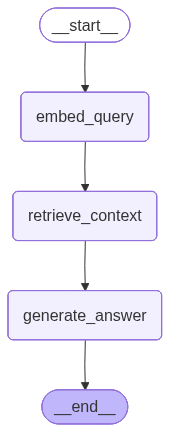

In [10]:
from chatbot_langgraph import chatbot_graph
from IPython.display import Image, display

display(Image(chatbot_graph.get_graph(xray=True).draw_mermaid_png()))

## 8. LangGraph — run each node manually (step-by-step)

In [11]:
from chatbot_langgraph import embed_query, retrieve_context, generate_answer

question = "ce se intampla daca fur?"

# Step 1: embed
state = {"question": question, "embedding": [], "context": [], "messages": []}
state.update(embed_query(state))
print(f"[embed_query]     dim={len(state['embedding'])}  first_5={state['embedding'][:5]}")

[embed_query]     dim=3072  first_5=[-0.01342901960015297, -0.02036057971417904, -0.011153507977724075, -0.0020112022757530212, 0.02701207436621189]


In [12]:
# Step 2: retrieve
state.update(retrieve_context(state))
print(f"[retrieve_context] {len(state['context'])} hits")
for i, hit in enumerate(state["context"]):
    print(f"  [{i}] score={hit['score']:.4f}  text={str(hit.get('text',''))[:200]}")

[retrieve_context] 2 hits
  [0] score=0.5717  text=Articol 228 - Furtul
(1) Luarea unui bun mobil din posesia sau detenţia altuia, fără consimţământul acestuia, în scopul de a şi-l însuşi pe nedrept, se pedepseşte cu închisoare de la 6 luni la 3 ani s
  [1] score=0.5716  text=Articol 228 - Furtul
(1) Luarea unui bun mobil din posesia sau detenţia altuia, fără consimţământul acestuia, în scopul de a şi-l însuşi pe nedrept, se pedepseşte cu închisoare de la 6 luni la 3 ani s


In [13]:
# Step 3: generate
result = generate_answer(state)
state["messages"] = result["messages"]
print(f"[generate_answer]")
print(state["messages"][-1].content)

[generate_answer]
Dacă furi, comiți infracțiunea de furt, care este pedepsită cu închisoare de la 6 luni la 3 ani sau cu amendă, conform articolului 228 din Codul Penal român.


## 9. LangGraph — full pipeline via `run_chatbot`

In [14]:
from chatbot_langgraph import run_chatbot

question = "ce pedeapsa primesc daca fur un telefon?"

answer, context = run_chatbot(question)

print("=== ANSWER ===")
print(answer)
print("\n=== CONTEXT ===")
for i, hit in enumerate(context):
    print(f"[{i}] score={hit['score']:.4f}  {str(hit.get('text',''))[:300]}")

Furtul unui telefon mobil este în general încadrat la infracțiunea de furt simplu, conform art. 228 din Codul Penal. Pedeapsa pentru furt poate varia de la 6 luni la 3 ani de închisoare sau amendă penală, în funcție de circumstanțele cazului și gravitatea faptei. Dacă furtul este săvârșit în anumite condiții agravante, conform art. 229, limitele pedepsei pot fi mai mari.
=== ANSWER ===
Furtul unui telefon mobil este în general încadrat la infracțiunea de furt simplu, conform art. 228 din Codul Penal. Pedeapsa pentru furt poate varia de la 6 luni la 3 ani de închisoare sau amendă penală, în funcție de circumstanțele cazului și gravitatea faptei. Dacă furtul este săvârșit în anumite condiții agravante, conform art. 229, limitele pedepsei pot fi mai mari.

=== CONTEXT ===
[0] score=0.5860  Articol 230 - Furtul în scop de folosinţă
(1) Furtul care are ca obiect un vehicul, săvârşit în scopul de a-l folosi pe nedrept, se sancţionează cu pedeapsa prevăzută în art. 228 sau art. 229, după caz,

## 10. LangGraph — streaming response

In [12]:
from chatbot_langgraph import chatbot_graph

question = "care este diferenta dintre furt si talharie?"

initial_state = {
    "question": question,
    "embedding": [],
    "context": [],
    "messages": [],
}

def stream_answer(state):
    """Generator that yields LLM token chunks word by word."""
    for chunk, metadata in chatbot_graph.stream(state, stream_mode="messages"):
        if chunk.content:
            yield chunk.content

print("Answer:\n")
for token in stream_answer(initial_state):
    print(token, end="", flush=True)
print()

Answer:

Diferența principală între furt și tâlhărie constă în modul de săvârșire a infracțiunii. Furtul implică sustragerea bunului fără consimțământul proprietarului, în timp ce tâlhăria implică sustragerea bunului prin întrebuințarea de violențe, amenințări sau punerea victimei în stare de inconștiență sau neputință de a se apăra. Practic, tâlhăria este un furt agravat de violență sau amenințare.


## 11. Gradio — install check

In [15]:
import importlib
import subprocess, sys

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])

import gradio as gr
print(f"Gradio version: {gr.__version__}")

Gradio version: 5.49.1


## 12. Gradio — chat interface

In [16]:
import gradio as gr
from chatbot_langgraph import chatbot_graph


def stream_response(user_message: str, history: list):
    initial_state = {
        "question": user_message,
        "embedding": [],
        "context": [],
        "messages": [],
    }

    history = history + [
        {"role": "user", "content": user_message},
        {"role": "assistant", "content": ""},
    ]

    for chunk, metadata in chatbot_graph.stream(initial_state, stream_mode="messages"):
        if chunk.content:
            history[-1]["content"] += chunk.content
            yield history


with gr.Blocks() as demo:
    chatbot = gr.Chatbot(type="messages")
    textbox = gr.Textbox(placeholder="Scrie o întrebare legată de Codul Penal...")

    textbox.submit(
        fn=stream_response,
        inputs=[textbox, chatbot],
        outputs=chatbot,
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
